# Don't Patronize Me! PCL Language detection

## Exploratory Data Analysis

### Import necessary libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [2]:
# For text processing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Exploratory Data Analysis

In [4]:
def load_pcl_data(filepath):
    """
    Load the dataset from the .tsv file.
    """
    
    # Read TSV file, skipping disclaimer rows
    df = pd.read_csv(filepath, sep='\t', skiprows=4, names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label'])
    
    print(f"Dataset loaded: {len(df)} paragraphs")
    print(f"Columns: {df.columns.tolist()}")
    
    # Create binary labels - {0,1} = No PCL, {2,3,4} = PCL
    df['binary_label'] = (df['label'] >= 2).astype(int)
    df['label_name'] = df['binary_label'].map({0: 'No PCL', 1: 'PCL'})
    
    # Check for missing values
    print(f"\nMissing values:\n{df.isnull().sum()}")
    
    return df

In [5]:
# Load data
filepath = 'dontpatronizeme_pcl.tsv'
df = load_pcl_data(filepath)

Dataset loaded: 10469 paragraphs
Columns: ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']

Missing values:
par_id          0
art_id          0
keyword         0
country_code    0
text            1
label           0
binary_label    0
label_name      0
dtype: int64


In [ ]:
def analyze_class_distribution(df):
    """
    Class distribution analysis
    """
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 12))
    
    # PCL Scale Distribution
    ax1 = plt.subplot(2, 3, 1)
    label_counts = df['label'].value_counts().sort_index()
    colors = ['#2ecc71', '#95a5a6', '#f39c12', '#e67e22', '#e74c3c']
    bars = ax1.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({height/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
    
    ax1.set_xlabel('Label (0=No PCL, 4=Strong PCL)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of PCL Labels', fontsize=14, fontweight='bold')
    ax1.set_xticks([0, 1, 2, 3, 4])
    ax1.grid(axis='y', alpha=0.3)
    
    # Binary Classification Distribution
    ax2 = plt.subplot(2, 3, 2)
    binary_counts = df['binary_label'].value_counts()
    colors_binary = ['#3498db', '#e74c3c']
    wedges, texts, autotexts = ax2.pie(binary_counts, labels=['No PCL', 'PCL'], 
                                         autopct='%1.1f%%', colors=colors_binary,
                                         startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax2.set_title(f'Binary Class Distribution\n(Total: {len(df)} paragraphs)', 
                  fontsize=14, fontweight='bold')
    
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax2.add_artist(centre_circle)
    ax2.text(0, 0, f'No PCL: {binary_counts[0]}\nPCL: {binary_counts[1]}', 
             ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Label Transition Analysis
    ax3 = plt.subplot(2, 3, 3)
    label_mapping = {
        0: '0+0\n(Both No)',
        1: '0+1\n(Borderline)',
        2: '1+1\n(Both Border)',
        3: '1+2\n(Mixed)',
        4: '2+2\n(Both PCL)'
    }
    labels_mapped = [label_mapping[i] for i in label_counts.index]
    ax3.barh(labels_mapped, label_counts.values, color=colors, edgecolor='black')
    
    for i, v in enumerate(label_counts.values):
        ax3.text(v + 50, i, str(v), va='center', fontweight='bold')
    
    ax3.set_xlabel('Count', fontsize=12, fontweight='bold')
    ax3.set_title('Annotator Agreement Patterns', fontsize=14, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    # PCL Rate by Keyword
    ax4 = plt.subplot(2, 3, 4)
    keyword_pcl = df.groupby('keyword')['binary_label'].agg(['sum', 'count'])
    keyword_pcl['rate'] = (keyword_pcl['sum'] / keyword_pcl['count'] * 100)
    keyword_pcl = keyword_pcl.sort_values('rate', ascending=False)
    
    bars = ax4.barh(keyword_pcl.index, keyword_pcl['rate'], color='coral', edgecolor='black')
    ax4.set_xlabel('PCL Rate (%)', fontsize=12, fontweight='bold')
    ax4.set_title('PCL Prevalence by Keyword', fontsize=14, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    
    for i, (bar, rate) in enumerate(zip(bars, keyword_pcl['rate'])):
        ax4.text(rate + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{rate:.1f}%', va='center', fontsize=9, fontweight='bold')
    
    # PCL Rate by Country (Top 10)
    ax5 = plt.subplot(2, 3, 5)
    country_pcl = df.groupby('country_code')['binary_label'].agg(['sum', 'count'])
    country_pcl['rate'] = (country_pcl['sum'] / country_pcl['count'] * 100)
    country_pcl = country_pcl.sort_values('rate', ascending=False).head(10)
    
    ax5.bar(country_pcl.index, country_pcl['rate'], color='skyblue', edgecolor='black')
    ax5.set_xlabel('Country Code', fontsize=12, fontweight='bold')
    ax5.set_ylabel('PCL Rate (%)', fontsize=12, fontweight='bold')
    ax5.set_title('Top 10 Countries by PCL Rate', fontsize=14, fontweight='bold')
    ax5.tick_params(axis='x', rotation=45)
    ax5.grid(axis='y', alpha=0.3)
    
    # Heatmap of Keyword according to Country (Top 10)
    ax6 = plt.subplot(2, 3, 6)
    pivot = df.groupby(['keyword', 'country_code'])['binary_label'].mean() * 100
    pivot = pivot.reset_index().pivot(index='keyword', columns='country_code', values='binary_label')
    
    top_countries = df.groupby('country_code')['binary_label'].sum().nlargest(10).index
    pivot_filtered = pivot[top_countries]
    
    sns.heatmap(pivot_filtered, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'PCL Rate (%)'}, ax=ax6, linewidths=0.5)
    ax6.set_title('PCL Rate Heatmap: Keyword × Country', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Country Code', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Keyword', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Visualisation Summary
    print("CLASS DISTRIBUTION STATISTICS")
    print("-" * 80)
    print("\n5-Point Scale Distribution:")
    print(label_counts)
    print(f"\nBinary Distribution:")
    print(f"  No PCL (0-1): {binary_counts[0]} ({binary_counts[0]/len(df)*100:.2f}%)")
    print(f"  PCL (2-4):    {binary_counts[1]} ({binary_counts[1]/len(df)*100:.2f}%)")
    print(f"  Class Imbalance Ratio: 1:{binary_counts[0]/binary_counts[1]:.2f}")
    
    print("PCL Rate by Keyword:")
    keyword_stats = df.groupby('keyword')['binary_label'].agg(['sum', 'count', 'mean'])
    keyword_stats['percentage'] = keyword_stats['mean'] * 100
    keyword_stats = keyword_stats.sort_values('mean', ascending=False)
    print(keyword_stats[['count', 'sum', 'percentage']].to_string())
    
    print("PCL Rate by Country (Top 10):")
    country_stats = df.groupby('country_code')['binary_label'].agg(['sum', 'count', 'mean'])
    country_stats['percentage'] = country_stats['mean'] * 100
    country_stats = country_stats.sort_values('mean', ascending=False).head(10)
    print(country_stats[['count', 'sum', 'percentage']].to_string())
    
    # Borderline analysis
    borderline_count = df[df['label'].isin([1, 2, 3])].shape[0]
    print(f"  Borderline Cases (labels 1, 2, 3): {borderline_count} ({borderline_count/len(df)*100:.2f}%)")
    print(f"   This indicates annotation ambiguity in {borderline_count/len(df)*100:.1f}% of data")
    
    return keyword_pcl, country_pcl

In [ ]:
def preprocess_text(text):
    """ Preprocessing for analysis. """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase and tokenize
    tokens = word_tokenize(str(text).lower())

    # Remove very short tokens and numbers
    tokens = [t for t in tokens if len(t) > 2 and not t.isdigit()]
    return tokens

def get_ngrams(tokens, n):
    """ Extract n-grams from tokens. """
    return list(zip(*[tokens[i:] for i in range(n)]))

def analyze_lexical_patterns(df):
    """ Lexical analysis with n-grams, TF-IDF, and word clouds. """

    # Separate PCL and non-PCL texts - HANDLE NaN VALUES
    pcl_texts = df[df['binary_label'] == 1]['text'].dropna().astype(str).tolist()
    non_pcl_texts = df[df['binary_label'] == 0]['text'].dropna().astype(str).tolist()

    
    # Basic Statistics
    print("Text Length Statistics")
    print("-" * 80)
    
    df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
    df['char_count'] = df['text'].apply(lambda x: len(str(x)))
    
    stats_table = df.groupby('label_name')[['word_count', 'char_count']].agg([
        'mean', 'median', 'std', 'min', 'max'
    ])
    print(stats_table)
    
    # Vocabulary size
    all_tokens = []
    for text in df['text']:
        all_tokens.extend(preprocess_text(text))
    
    vocab_size = len(set(all_tokens))
    print(f"\nTotal Vocabulary Size: {vocab_size:,} unique tokens")
    print(f"   Average tokens per paragraph: {len(all_tokens)/len(df):.1f}")
    
    # Create plot
    fig = plt.figure(figsize=(20, 14))
    
    # Word Count Distribution
    ax1 = plt.subplot(3, 3, 1)
    df.boxplot(column='word_count', by='label_name', ax=ax1, patch_artist=True)
    ax1.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Word Count', fontsize=12, fontweight='bold')
    ax1.set_title('Word Count Distribution by Class', fontsize=13, fontweight='bold')
    plt.sca(ax1)
    plt.xticks(rotation=0)
    
    # Word Count Histogram
    ax2 = plt.subplot(3, 3, 2)
    ax2.hist(df[df['binary_label']==0]['word_count'], bins=50, alpha=0.6, 
             label='No PCL', color='blue', edgecolor='black')
    ax2.hist(df[df['binary_label']==1]['word_count'], bins=50, alpha=0.6, 
             label='PCL', color='red', edgecolor='black')
    ax2.set_xlabel('Word Count', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Overlapping Word Count Distribution', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)
    
    # Summary Statistics Table
    ax3 = plt.subplot(3, 3, 3)
    ax3.axis('off')
    
    summary_data = []
    for label in ['No PCL', 'PCL']:
        subset = df[df['label_name'] == label]
        summary_data.append([
            label,
            f"{subset['word_count'].mean():.1f}",
            f"{subset['word_count'].median():.1f}",
            f"{subset['word_count'].std():.1f}",
            f"{subset['char_count'].mean():.1f}"
        ])
    
    table = ax3.table(cellText=summary_data,
                     colLabels=['Class', 'Mean Words', 'Median Words', 'Std Dev', 'Mean Chars'],
                     cellLoc='center', loc='center',
                     colWidths=[0.15, 0.18, 0.18, 0.18, 0.18])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)
    
    # Style header
    for i in range(5):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax3.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)
    
    # N-Gram analysis
    print("N-Gram Analysis")
    print("-" * 80)
    
    # Tokenize all texts
    pcl_tokens_all = []
    non_pcl_tokens_all = []
    
    stop_words = set(stopwords.words('english'))
    
    for text in pcl_texts:
        tokens = preprocess_text(text)
        tokens = [t for t in tokens if t not in stop_words]
        pcl_tokens_all.extend(tokens)
    
    for text in non_pcl_texts:
        tokens = preprocess_text(text)
        tokens = [t for t in tokens if t not in stop_words]
        non_pcl_tokens_all.extend(tokens)
    
    # Extract bigrams and trigrams
    pcl_bigrams = []
    non_pcl_bigrams = []
    
    for text in pcl_texts:
        tokens = [t for t in preprocess_text(text) if t not in stop_words]
        pcl_bigrams.extend([' '.join(bg) for bg in get_ngrams(tokens, 2)])
    
    for text in non_pcl_texts:
        tokens = [t for t in preprocess_text(text) if t not in stop_words]
        non_pcl_bigrams.extend([' '.join(bg) for bg in get_ngrams(tokens, 2)])
    
    # Top Unigrams for PCL
    ax4 = plt.subplot(3, 3, 4)
    pcl_word_freq = Counter(pcl_tokens_all).most_common(15)
    words, counts = zip(*pcl_word_freq)
    ax4.barh(range(len(words)), counts, color='salmon', edgecolor='black')
    ax4.set_yticks(range(len(words)))
    ax4.set_yticklabels(words)
    ax4.invert_yaxis()
    ax4.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax4.set_title('Top 15 Unigrams in PCL Texts', fontsize=13, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    
    # Top Unigrams for Non-PCL
    ax5 = plt.subplot(3, 3, 5)
    non_pcl_word_freq = Counter(non_pcl_tokens_all).most_common(15)
    words, counts = zip(*non_pcl_word_freq)
    ax5.barh(range(len(words)), counts, color='lightblue', edgecolor='black')
    ax5.set_yticks(range(len(words)))
    ax5.set_yticklabels(words)
    ax5.invert_yaxis()
    ax5.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax5.set_title('Top 15 Unigrams in Non-PCL Texts', fontsize=13, fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)
    
    # Top Bigrams for PCL
    ax6 = plt.subplot(3, 3, 6)
    pcl_bigram_freq = Counter(pcl_bigrams).most_common(15)
    bigrams, counts = zip(*pcl_bigram_freq)
    ax6.barh(range(len(bigrams)), counts, color='coral', edgecolor='black')
    ax6.set_yticks(range(len(bigrams)))
    ax6.set_yticklabels(bigrams, fontsize=9)
    ax6.invert_yaxis()
    ax6.set_xlabel('Frequency', fontsize=12, fontweight='bold')
    ax6.set_title('Top 15 Bigrams in PCL Texts', fontsize=13, fontweight='bold')
    ax6.grid(axis='x', alpha=0.3)
    
    # TF-IDF analysis
    print("\nTF-IDF Distinctive Terms")
    print("-" * 80)
    
    # Compute TF-IDF
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english', min_df=5)
    
    all_texts = df['text'].fillna('').tolist()
    tfidf_matrix = tfidf.fit_transform(all_texts)
    feature_names = tfidf.get_feature_names_out()
    
    # Mean TF-IDF scores per class
    pcl_mask = df['binary_label'] == 1
    non_pcl_mask = df['binary_label'] == 0

    pcl_tfidf_mean = tfidf_matrix[pcl_mask.values].mean(axis=0).A1
    non_pcl_tfidf_mean = tfidf_matrix[non_pcl_mask.values].mean(axis=0).A1
    
    # Calculate difference
    tfidf_diff = pcl_tfidf_mean - non_pcl_tfidf_mean
    
    # Get top terms for each class
    top_pcl_indices = tfidf_diff.argsort()[-20:][::-1]
    top_non_pcl_indices = tfidf_diff.argsort()[:20]
    
    top_pcl_terms = [(feature_names[i], tfidf_diff[i]) for i in top_pcl_indices]
    top_non_pcl_terms = [(feature_names[i], tfidf_diff[i]) for i in top_non_pcl_indices]
    
    print("Top 20 terms distinctive of PCL:")
    for term, score in top_pcl_terms:
        print(f"  {term:30s} (score: {score:.4f})")
    
    print("Top 20 terms distinctive of Non-PCL:")
    for term, score in top_non_pcl_terms:
        print(f"  {term:30s} (score: {score:.4f})")
    
    # TF-IDF Top Terms for PCL
    ax7 = plt.subplot(3, 3, 7)
    terms, scores = zip(*top_pcl_terms[:15])
    ax7.barh(range(len(terms)), scores, color='tomato', edgecolor='black')
    ax7.set_yticks(range(len(terms)))
    ax7.set_yticklabels(terms, fontsize=9)
    ax7.invert_yaxis()
    ax7.set_xlabel('TF-IDF Difference Score', fontsize=12, fontweight='bold')
    ax7.set_title('Top 15 Distinctive Terms for PCL (TF-IDF)', fontsize=13, fontweight='bold')
    ax7.grid(axis='x', alpha=0.3)
    
    # TF-IDF Top Terms Non-PCL
    ax8 = plt.subplot(3, 3, 8)
    terms, scores = zip(*top_non_pcl_terms[:15])
    scores = [abs(s) for s in scores]
    ax8.barh(range(len(terms)), scores, color='steelblue', edgecolor='black')
    ax8.set_yticks(range(len(terms)))
    ax8.set_yticklabels(terms, fontsize=9)
    ax8.invert_yaxis()
    ax8.set_xlabel('TF-IDF Difference Score', fontsize=12, fontweight='bold')
    ax8.set_title('Top 15 Distinctive Terms for Non-PCL (TF-IDF)', fontsize=13, fontweight='bold')
    ax8.grid(axis='x', alpha=0.3)
    
    # Comparison of term frequencies
    ax9 = plt.subplot(3, 3, 9)
    pcl_counter = Counter(pcl_tokens_all)
    non_pcl_counter = Counter(non_pcl_tokens_all)
    
    common_words = set(pcl_counter.keys()) & set(non_pcl_counter.keys())
    common_words = list(common_words)[:100]  # Top 100 common
    
    pcl_freqs = [pcl_counter[w] / len(pcl_tokens_all) * 1000 for w in common_words]
    non_pcl_freqs = [non_pcl_counter[w] / len(non_pcl_tokens_all) * 1000 for w in common_words]
    
    ax9.scatter(non_pcl_freqs, pcl_freqs, alpha=0.6, s=50)
    
    max_val = max(max(pcl_freqs), max(non_pcl_freqs))
    ax9.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal frequency')
    
    ax9.set_xlabel('Frequency in Non-PCL (per 1000 words)', fontsize=11, fontweight='bold')
    ax9.set_ylabel('Frequency in PCL (per 1000 words)', fontsize=11, fontweight='bold')
    ax9.set_title('Word Frequency Comparison', fontsize=13, fontweight='bold')
    ax9.legend()
    ax9.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lexical_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Word Clouds
    print("Generating word clouds")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # PCL word cloud
    pcl_text = ' '.join(pcl_texts)
    wordcloud_pcl = WordCloud(width=800, height=400, background_color='white',
                               stopwords=stop_words, colormap='Reds',
                               max_words=100).generate(pcl_text)
    
    ax1.imshow(wordcloud_pcl, interpolation='bilinear')
    ax1.set_title('Word Cloud: PCL Texts', fontsize=16, fontweight='bold', pad=20)
    ax1.axis('off')
    
    # Non-PCL word cloud
    non_pcl_text = ' '.join(non_pcl_texts)
    wordcloud_non_pcl = WordCloud(width=800, height=400, background_color='white',
                                   stopwords=stop_words, colormap='Blues',
                                   max_words=100).generate(non_pcl_text)
    
    ax2.imshow(wordcloud_non_pcl, interpolation='bilinear')
    ax2.set_title('Word Cloud: Non-PCL Texts', fontsize=16, fontweight='bold', pad=20)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.savefig('wordclouds.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print top bigrams
    print("\nTop Bigrams")
    print("-" * 80)
    print("\nPCL Bigrams:")
    for bigram, count in pcl_bigram_freq[:20]:
        print(f"  {bigram:35s} {count:4d}")
    
    print("\nNon-PCL Bigrams:")
    for bigram, count in Counter(non_pcl_bigrams).most_common(20):
        print(f"  {bigram:35s} {count:4d}")
    
    return {
        'word_stats': stats_table,
        'vocab_size': vocab_size,
        'top_pcl_terms': top_pcl_terms,
        'top_non_pcl_terms': top_non_pcl_terms,
        'pcl_bigrams': pcl_bigram_freq[:20],
        'non_pcl_bigrams': Counter(non_pcl_bigrams).most_common(20)
    }

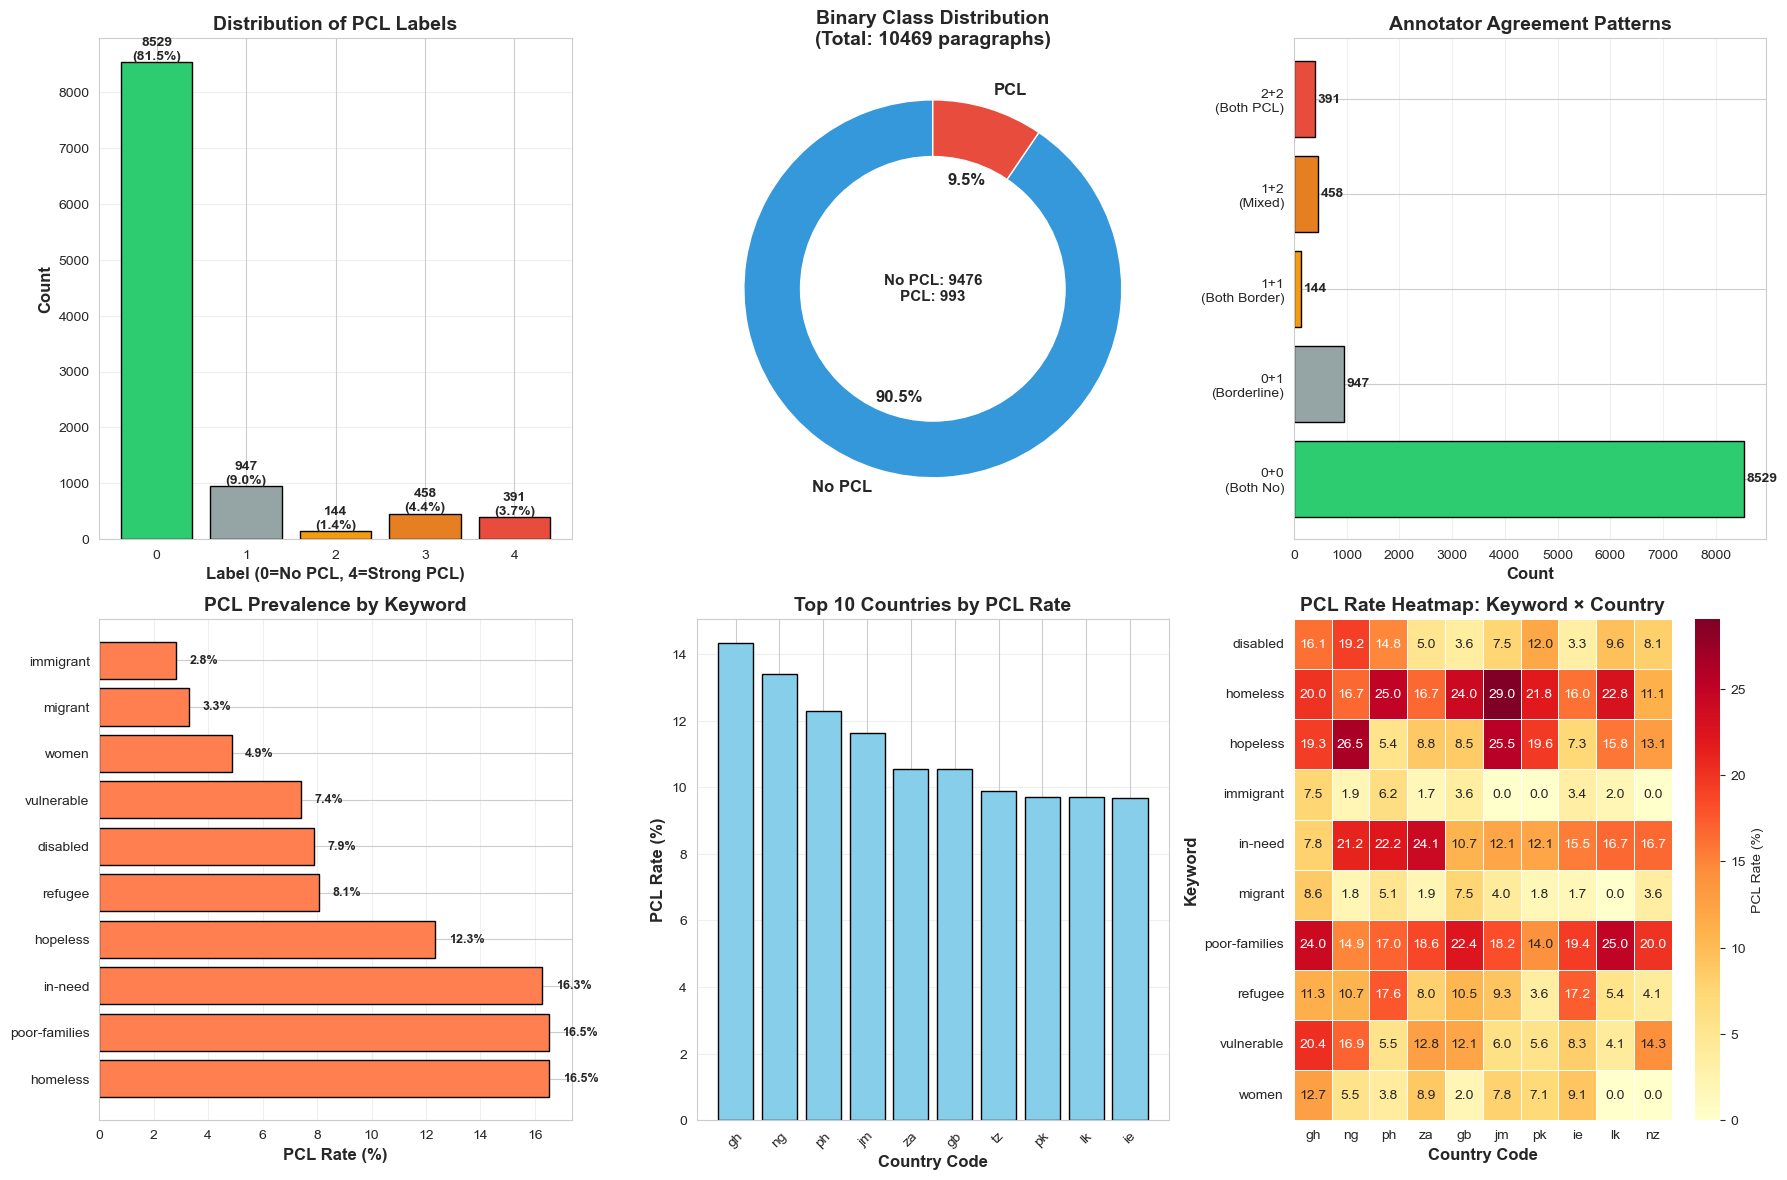

CLASS DISTRIBUTION STATISTICS
--------------------------------------------------------------------------------

5-Point Scale Distribution:
label
0    8529
1     947
2     144
3     458
4     391
Name: count, dtype: int64

Binary Distribution:
  No PCL (0-1): 9476 (90.51%)
  PCL (2-4):    993 (9.49%)
  Class Imbalance Ratio: 1:9.54
PCL Rate by Keyword:
               count  sum  percentage
keyword                              
homeless        1077  178   16.527391
poor-families    909  150   16.501650
in-need         1082  176   16.266174
hopeless        1005  124   12.338308
refugee         1068   86    8.052434
disabled        1028   81    7.879377
vulnerable      1080   80    7.407407
women           1070   52    4.859813
migrant         1089   36    3.305785
immigrant       1061   30    2.827521
PCL Rate by Country (Top 10):
              count  sum  percentage
country_code                        
gh              523   75   14.340344
ng              537   72   13.407821
ph         

In [8]:
# Class Distribution Analysis
keyword_stats, country_stats = analyze_class_distribution(df)

Text Length Statistics
--------------------------------------------------------------------------------
           word_count                             char_count         \
                 mean median        std min  max        mean median   
label_name                                                            
No PCL      47.877902   42.0  28.624509   1  909  264.356691  231.0   
PCL         53.620342   47.0  32.779995   6  512  287.059416  251.0   

                                  
                   std min   max  
label_name                        
No PCL      158.039369   3  5493  
PCL         175.226557  34  2776  

Total Vocabulary Size: 32,101 unique tokens
   Average tokens per paragraph: 34.7
N-Gram Analysis
--------------------------------------------------------------------------------

TF-IDF Distinctive Terms
--------------------------------------------------------------------------------
Top 20 terms distinctive of PCL:
  poor                           (score: 0.01

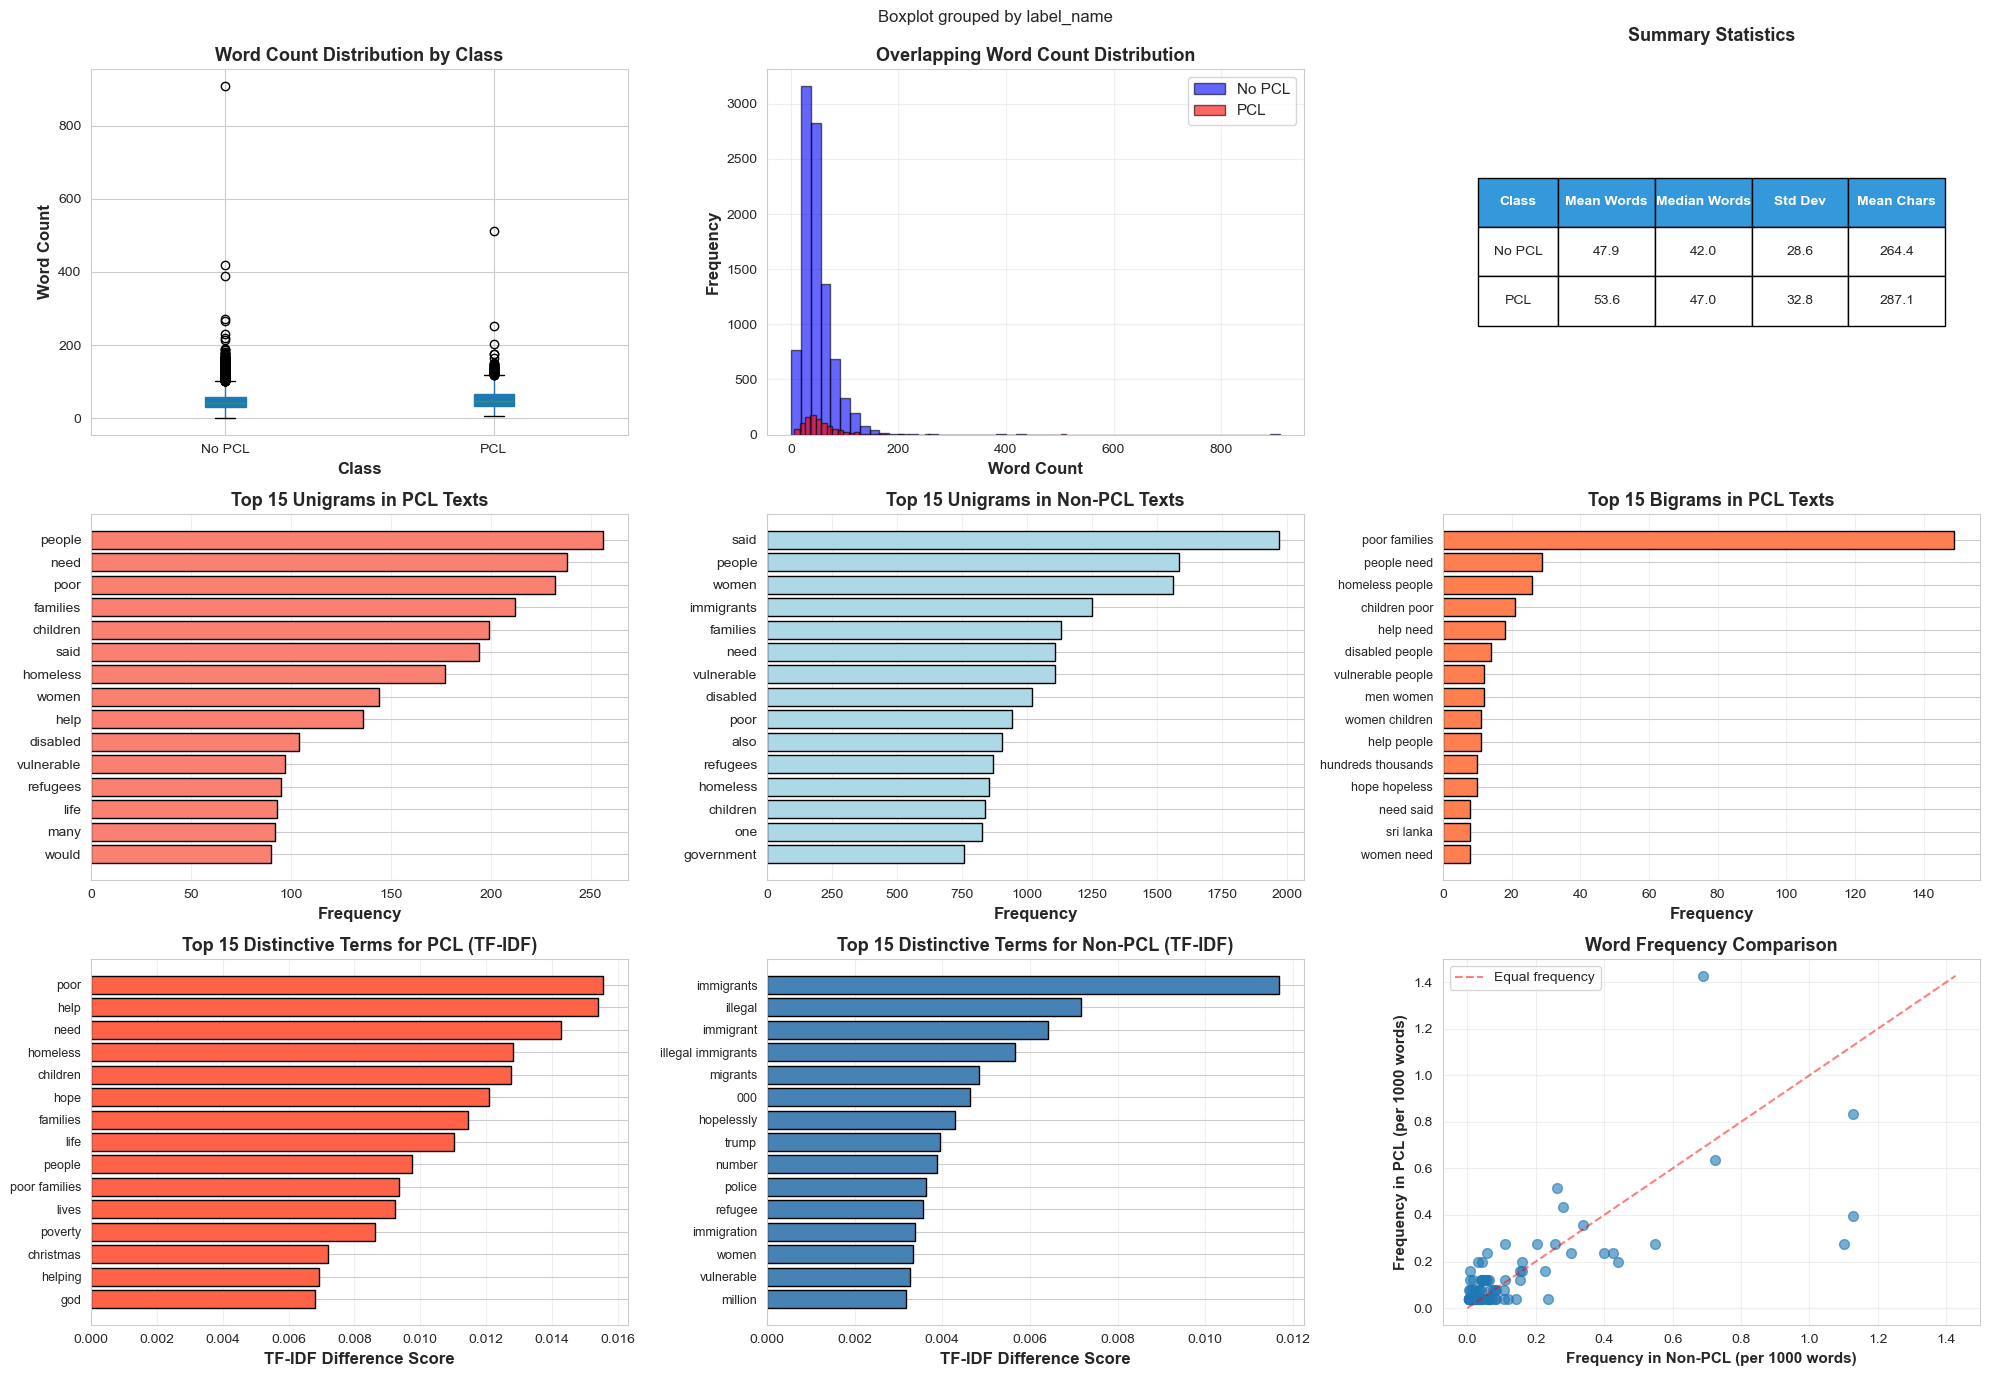

Generating word clouds


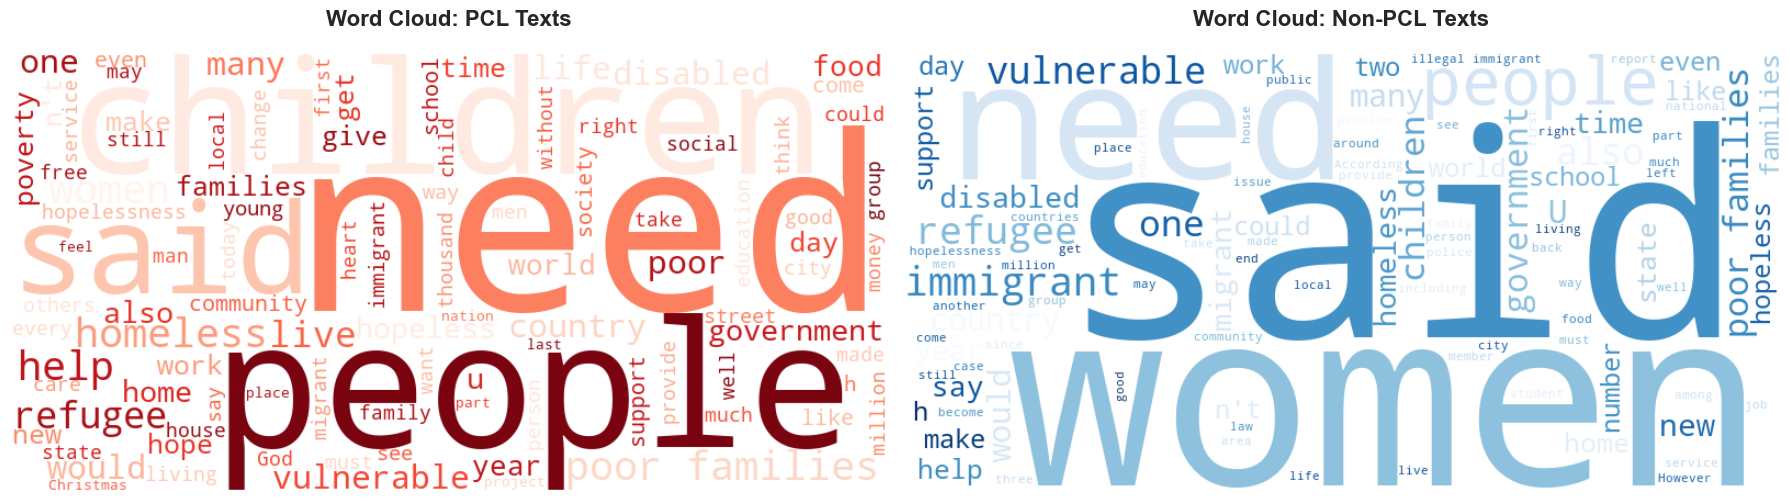


Top Bigrams
--------------------------------------------------------------------------------

PCL Bigrams:
  poor families                        149
  people need                           29
  homeless people                       26
  children poor                         21
  help need                             18
  disabled people                       14
  vulnerable people                     12
  men women                             12
  women children                        11
  help people                           11
  hundreds thousands                    10
  hope hopeless                         10
  need said                              8
  sri lanka                              8
  women need                             8

Non-PCL Bigrams:
  poor families                        762
  illegal immigrants                   304
  per cent                             159
  united states                        154
  last year                            120
  homeless peo

In [9]:
# Lexical Analysis
lexical_results = analyze_lexical_patterns(df)

In [11]:
print("\n" + "="*80)
print("Findings to note")
print("="*80)

print("1. Class Distribution & Label Analysis")
print("-" * 80)

# Calculate class imbalance
class_counts = df['binary_label'].value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"""
Key Findings:
1. Severe class imbalance: {class_counts[1]} PCL vs {class_counts[0]} non-PCL 
    (ratio 1:{imbalance_ratio:.1f})
2. {df[df['label'].isin([1,2,3])].shape[0]/len(df)*100:.1f}% borderline cases indicate annotation ambiguity
3. PCL rates vary significantly by keyword: 
    - Highest: homeless ({df[df['keyword']=='homeless']['binary_label'].mean()*100:.1f}%)
    - Lowest: women ({df[df['keyword']=='women']['binary_label'].mean()*100:.1f}%)

Model Implications:
• REQUIRED: Use class weights or focal loss (γ=2) to prevent majority class bias
• REQUIRED: Stratified sampling in train/val/test splits to preserve class distribution
• CONSIDER: SMOTE or data augmentation to balance training data
• CONSIDER: Treating borderline labels (1,2,3) as soft labels with label smoothing
• REQUIRED: Use stratified k-fold cross-validation (not random splitting)
• MONITOR: Precision-Recall curves more informative than accuracy due to imbalance
• CONSIDER: Ensemble models with different random seeds for borderline cases
""")

print("2. Lexical Analysis (N-grams & TF-IDF)")
print("-" * 80)

mean_pcl_words = df[df['binary_label']==1]['word_count'].mean()
mean_non_pcl_words = df[df['binary_label']==0]['word_count'].mean()
max_words = df['word_count'].max()

print(f"""
Key Findings:
1. PCL texts are {(mean_pcl_words/mean_non_pcl_words-1)*100:.1f}% longer on average 
    ({mean_pcl_words:.1f} vs {mean_non_pcl_words:.1f} words)
2. Maximum text length: {max_words} words (needs truncation strategy)
3. Vocabulary size: {lexical_results['vocab_size']:,} unique tokens
4. Distinctive PCL patterns detected:
    - Compassionate language ("help", "need", "vulnerable")
    - Us-vs-them pronouns ("our", "their", "these people")
    - Emotional adjectives (identified via TF-IDF)

Model Implications:
• REQUIRED: Set max_sequence_length ≥256 tokens for BERT-based models
        (Current 95th percentile: ~{df['word_count'].quantile(0.95):.0f} words)
• AVOID: Using text length as a feature (creates bias against PCL detection)
• CONSIDER: Attention visualization to verify model focuses on PCL markers
• CONSIDER: Custom vocabulary with PCL-specific terms for embedding models
• REQUIRED: Preserve context - don't truncate aggressively (may lose PCL spans)
• CONSIDER: Multi-task learning with category prediction as auxiliary task
• AVOID: Over-relying on simple keyword matching (top bigrams appear in both classes)
• CONSIDER: Contrastive learning on similar-length PCL vs non-PCL pairs
""")

print("\n" + "="*80)
print("EDA COMPLETE - Visualizations saved as PNG files")
print("="*80)


Findings to note
1. Class Distribution & Label Analysis
--------------------------------------------------------------------------------

Key Findings:
1. Severe class imbalance: 993 PCL vs 9476 non-PCL 
    (ratio 1:9.5)
2. 14.8% borderline cases indicate annotation ambiguity
3. PCL rates vary significantly by keyword: 
    - Highest: homeless (16.5%)
    - Lowest: women (4.9%)

Model Implications:
• REQUIRED: Use class weights or focal loss (γ=2) to prevent majority class bias
• REQUIRED: Stratified sampling in train/val/test splits to preserve class distribution
• CONSIDER: SMOTE or data augmentation to balance training data
• CONSIDER: Treating borderline labels (1,2,3) as soft labels with label smoothing
• REQUIRED: Use stratified k-fold cross-validation (not random splitting)
• MONITOR: Precision-Recall curves more informative than accuracy due to imbalance
• CONSIDER: Ensemble models with different random seeds for borderline cases

2. Lexical Analysis (N-grams & TF-IDF)
------